# Module 7 — Unsupervised Learning
## In-Class Practice: Clustering & PCA

**Goal:** Practice applying K-Means, DBSCAN, Hierarchical Clustering, PCA, and
cluster evaluation metrics on **two different datasets**.

By the end of this activity, you should be able to:
- Run K-Means and Hierarchical Clustering on numeric data.
- Run DBSCAN on a non-convex dataset and compare with K-Means.
- Use PCA as a preprocessing / visualization step.
- Evaluate cluster quality with **silhouette**, **Davies–Bouldin**, and
  **Calinski–Harabasz** indices.

👉 Work through the steps in order and fill in all cells marked `# TODO`.
Do **not** modify the dataset generation cells so that everyone works with
the same data.

In [1]:
# Step 0 — Imports (you may add more if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

plt.rcParams['figure.figsize'] = (6, 5)
%matplotlib inline

---
## Part A — Dataset 1: Numeric Blobs (Good for K-Means / Hierarchical)

We start with a synthetic **5-dimensional** dataset with 4 Gaussian-like
clusters. This is similar to the kind of data where **K-Means** and
**Agglomerative (Ward) Hierarchical Clustering** tend to work well.

In [2]:
# DO NOT MODIFY THIS CELL
# Dataset 1: 5D numeric blobs with 4 underlying clusters
X1, y1_true = make_blobs(
    n_samples=500,
    centers=4,
    n_features=5,
    cluster_std=[1.0, 1.4, 1.2, 0.8],
    random_state=42
)

df1 = pd.DataFrame(X1, columns=[f'feat_{i}' for i in range(X1.shape[1])])
df1['true_label'] = y1_true
df1.head()

,feat_0,feat_1,feat_2,feat_3,feat_4,true_label
0,-10.868069,-7.230056,4.887924,1.514883,2.593914,1
1,-9.732768,6.790994,7.665759,-6.395612,-6.472141,2
2,-8.485418,9.049868,6.969724,-5.367180,-7.165209,2
3,-7.461608,11.391708,6.100337,-6.475872,-5.800972,2
4,-3.348415,8.705074,4.971142,2.948715,-7.358801,0


### A.1 — Quick Exploration & Visualization
1. Print the shape of `df1` and basic `.describe()` for the feature columns.
2. Make a scatter plot of **two chosen features** (e.g., `feat_0` vs `feat_1`).
3. Make a second scatter coloured by `true_label` (just for intuition —
   **do not** use `true_label` during clustering itself).

Data shape:  (500, 6) 

Data Head:  
       feat_0     feat_1    feat_2    feat_3    feat_4  true_label
0 -10.868069  -7.230056  4.887924  1.514883  2.593914           1
1  -9.732768   6.790994  7.665759 -6.395612 -6.472141           2
2  -8.485418   9.049868  6.969724 -5.367180 -7.165209           2
3  -7.461608  11.391708  6.100337 -6.475872 -5.800972           2
4  -3.348415   8.705074  4.971142  2.948715 -7.358801           0 

Data stats:  
            feat_0      feat_1      feat_2      feat_3      feat_4  true_label
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000
mean    -6.331576    1.455673    4.795240   -0.658470   -3.265579    1.500000
std      2.784447    8.046221    2.911406    3.397327    4.638623    1.119154
min    -13.093931  -12.231759   -1.588242   -9.199932   -9.607379    0.000000
25%     -8.350976   -5.423490    2.620542   -3.224257   -6.610550    0.750000
50%     -6.562101    2.184031    5.354549   -0.081998   -4.942355    1.500000
75%

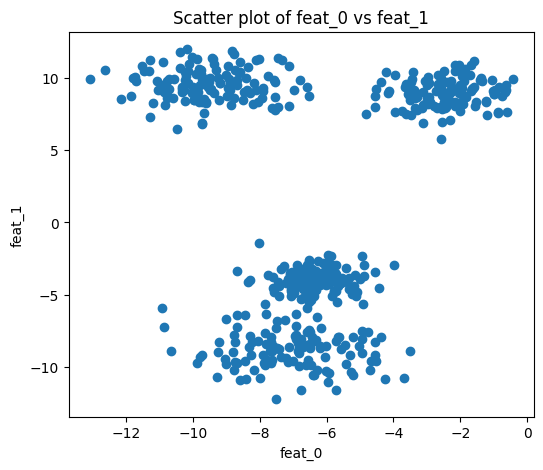

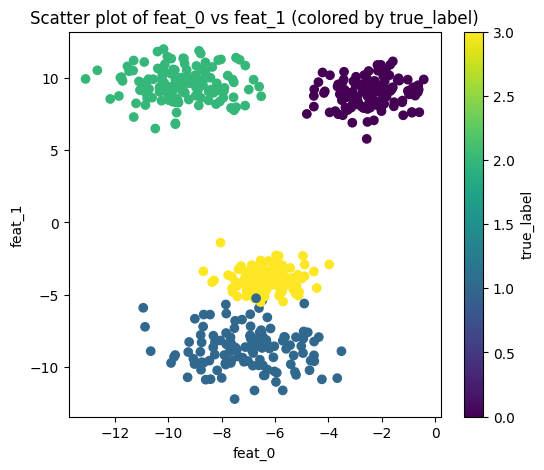

In [16]:
# TODO A.1
# 1) Inspect df1 (shape, head, describe).
print("Data shape: ",df1.shape,"\n")

print("Data Head: ","\n", df1.head(),"\n")

print("Data stats: ","\n",df1.describe(),"\n")

# 2) Scatter feat_0 vs feat_1 (no colour).

plt.figure()
plt.scatter(df1["feat_0"], df1["feat_1"])
plt.xlabel("feat_0")
plt.ylabel("feat_1")
plt.title("Scatter plot of feat_0 vs feat_1")
plt.show()

# 3) Scatter feat_0 vs feat_1 coloured by true_label.

plt.figure()
plt.scatter(df1["feat_0"], df1["feat_1"], c=df1["true_label"])
plt.xlabel("feat_0")
plt.ylabel("feat_1")
plt.title("Scatter plot of feat_0 vs feat_1 (colored by true_label)")
plt.colorbar(label="true_label")
plt.show()

### A.2 — Standardize Features
Most distance-based clustering methods assume features are on comparable
scales.

1. Select only the feature columns (no `true_label`).
2. Use `StandardScaler` to create `X1_scaled`.
3. Print the (approximate) mean and standard deviation of each scaled feature.

In [ ]:
# TODO A.2
# 1) Extract numeric features from df1.
X1 = df1.drop(columns=['true_label']).values

# 2) Fit StandardScaler and create X1_scaled.
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

# 3) Print approximate mean and std per feature.
print("Approximate mean per feature:", X1_scaled.mean(axis=0))
print("Approximate std per feature:", X1_scaled.std(axis=0))


Approximate mean per feature: [-9.63118474e-16  2.81996648e-17  1.66089364e-16 -1.23559149e-16
 -1.90042426e-16]
Approximate std per feature: [1. 1. 1. 1. 1.]


### A.3 — K-Means for Multiple k (Elbow & Silhouette)
Run K-Means on `X1_scaled` for `k` values in a small range (e.g., 2 to 8):

1. For each k, fit `KMeans` (use `random_state=42`, `n_init=10`).
2. Record **inertia** and **silhouette score**.
3. Plot inertia vs k ("Elbow plot").
4. Plot silhouette vs k.
5. Based on the plots, choose a **reasonable k** for this dataset and
   explain your choice in a short markdown cell.

c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\bruno\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

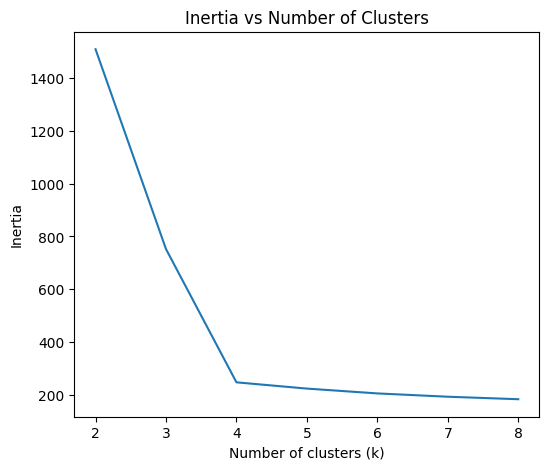

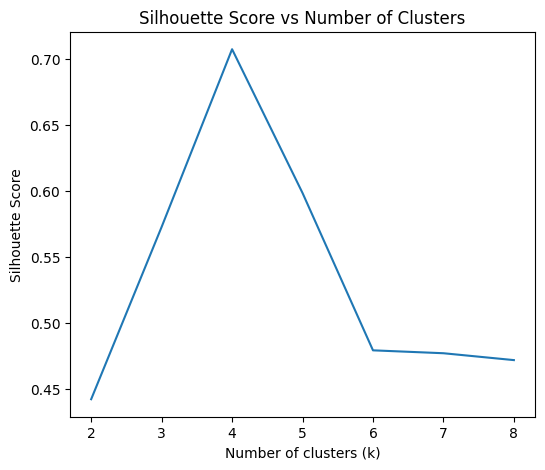

In [20]:
# TODO A.3
# 1) Loop over k values (e.g., 2..8) and fit KMeans.
# 2) Store inertia and silhouette for each k.
# 3) Make two line plots: inertia vs k, silhouette vs k.

# Choose range of k values
k_values = range(2, 9)

inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X1_scaled)  # X should already be defined
    
    # Store inertia
    inertias.append(kmeans.inertia_)
    
    # Compute and store silhouette score
    labels = kmeans.labels_
    silhouettes.append(silhouette_score(X1_scaled, labels))

# --- Plot 1: Inertia vs k ---
plt.figure()
plt.plot(k_values, inertias)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Inertia vs Number of Clusters")
plt.show()

# --- Plot 2: Silhouette vs k ---
plt.figure()
plt.plot(k_values, silhouettes)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()
pass

#### A.3 — Your Choice of k
Write 2–3 sentences explaining which **k** you chose based on the elbow and
silhouette plots.

_TODO: briefly justify your chosen k here._

### A.4 — Final K-Means Model & Cluster Quality
Using your chosen `k` from A.3:

1. Fit a final `KMeans` model on `X1_scaled`.
2. Store labels in `df1['kmeans_label']`.
3. Compute and print:
   - Silhouette score
   - Davies–Bouldin index
   - Calinski–Harabasz index
4. Make a **PCA 2D scatter plot** coloured by `kmeans_label`.

In [ ]:
# TODO A.4
# 1) Fit KMeans with your chosen k and add labels to df1.
# 2) Compute silhouette, DB index, and CH index.
# 3) Run PCA(n_components=2) on X1_scaled and make a scatter plot
#    coloured by kmeans_label.

pass

### A.5 — Agglomerative (Hierarchical) Clustering
Now apply **AgglomerativeClustering** with `linkage='ward'`:

1. Use the **same number of clusters** as your final K-Means.
2. Fit on `X1_scaled` and store labels as `df1['agg_label']`.
3. Compute silhouette, Davies–Bouldin, and Calinski–Harabasz indices.
4. Make a PCA 2D scatter plot coloured by `agg_label`.
5. Briefly compare K-Means vs Agglomerative (which looks better and why?).

In [ ]:
# TODO A.5
# 1) Fit AgglomerativeClustering with the same number of clusters.
# 2) Save labels and compute the three metrics.
# 3) Plot PCA(2D) projection coloured by agg_label.

pass

#### A.5 — Short Comparison
_TODO: in 2–3 bullet points, compare K-Means vs Agglomerative on Dataset 1._

---
## Part B — Dataset 2: Two Moons (Good for DBSCAN)

Now we use a classic **non-convex** dataset (two interleaving half-moons).
This is the situation where **DBSCAN** can shine and K-Means may struggle.

In [ ]:
# DO NOT MODIFY THIS CELL
# Dataset 2: 2D non-convex "two moons" dataset
X2, y2_true = make_moons(n_samples=400, noise=0.08, random_state=42)

df2 = pd.DataFrame(X2, columns=['x1', 'x2'])
df2['true_label'] = y2_true
df2.head()

### B.1 — Visualize the Two Moons
1. Scatter plot `x1` vs `x2` (no colour).
2. Scatter plot coloured by `true_label` to see the underlying structure.

In [ ]:
# TODO B.1
# 1) Scatter without colours.
# 2) Scatter coloured by true_label.

pass

### B.2 — K-Means on the Moons
1. Standardize the two features and store as `X2_scaled`.
2. Run `KMeans(n_clusters=2, random_state=42, n_init=10)` on `X2_scaled`.
3. Store labels in `df2['kmeans_label']`.
4. Compute silhouette, Davies–Bouldin, and Calinski–Harabasz indices.
5. Make a scatter plot of `x1` vs `x2` coloured by `kmeans_label`.
6. Briefly comment: does K-Means capture the true moon shapes?

In [ ]:
# TODO B.2
# 1) Standardize X2 and run KMeans with k=2.
# 2) Save labels and compute the three metrics.
# 3) Plot x1 vs x2 coloured by kmeans_label.

pass

### B.3 — DBSCAN on the Moons
1. Choose initial values for `eps` and `min_samples` (e.g., eps=0.3, min_samples=5).
2. Fit `DBSCAN` on `X2_scaled` and store labels in `df2['dbscan_label']`.
3. Count how many points are labeled as **noise** (`label == -1`).
4. Compute silhouette score **only on non-noise points** (if at least 2 clusters).
5. Compute Davies–Bouldin and Calinski–Harabasz for non-noise points as well.
6. Make a scatter plot coloured by `dbscan_label` (treat noise as a separate colour/marker).

In [ ]:
# TODO B.3
# 1) Fit DBSCAN on X2_scaled.
# 2) Count noise points and compute metrics on non-noise points (if valid).
# 3) Scatter x1 vs x2 coloured by dbscan_label (noise included).

pass

### B.4 — Compare K-Means vs DBSCAN on Dataset 2
In 3–5 bullet points, compare the two algorithms on the **two moons**:
- Which one matches the `true_label` structure more closely?
- How do the internal metrics compare?
- How sensitive is DBSCAN to your choice of `eps` and `min_samples`?

_TODO: add your comparison notes here._

---
## Part C — Overall Reflection
In 3–6 bullet points, summarise what you learned from **both datasets**:
- When does K-Means work well vs poorly?
- When is DBSCAN more appropriate?
- How useful were the internal metrics in guiding your choices?
- Did PCA help interpret the clusters in Dataset 1?

_You can answer in the space below or in a separate document, depending on
your instructor’s instructions._